In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")


# Set style for better-looking plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# Load the dataset
data=pd.read_csv('../data/student_performance_dataset.csv')
#first  few rows
print("First few rows:",data.head())


#Handling missing values
print("Missing values before handling:\n",data.isnull().sum())

# Fill missing values with median for numerical columns
numerical_cols= data.select_dtypes(include=[np.number]).columns
for col in numerical_cols:
	data[col].fillna(data[col].median(), inplace=True)
	print(f"Filled missing values in {col} with median: {data[col].median()}")


First few rows:   student_id     name  study_hours  attendance_percentage  previous_marks  \
0       S001  Vikram1          8.8                     90              85   
1       S002   Arjun2          8.0                     70              93   
2       S003   Priya3          4.6                     64              40   
3       S004   Sneha4          2.5                     99              87   
4       S005   Sneha5          5.3                     95              83   

   assignments_completed  sleep_hours  activity_participation  \
0                      7            4                       2   
1                      9            8                       9   
2                      6            6                      10   
3                      3            4                       2   
4                     10            4                       7   

   internet_usage_hours  quiz_score  internal_assessment  performance_score  \
0                   4.4          54                

In [44]:
# Fill categorical missing values with mode
data['grade'].fillna(data['grade'].mode()[0], inplace=True)
print("\nMissing values after handling:")
print(data.isnull().sum())


Missing values after handling:
student_id                0
name                      0
study_hours               0
attendance_percentage     0
previous_marks            0
assignments_completed     0
sleep_hours               0
activity_participation    0
internet_usage_hours      0
quiz_score                0
internal_assessment       0
performance_score         0
grade                     0
dtype: int64


In [45]:

# Step 2: Remove duplicates
initial_len = len(data)
data.drop_duplicates(inplace=True)
print(f"\nRemoved {initial_len - len(data)} duplicate rows")




Removed 0 duplicate rows


In [46]:
#Encode categorical values (grade)
from sklearn.preprocessing import LabelEncoder
le =LabelEncoder()
data['grade_encoded']=le.fit_transform(data['grade'])
#mapping: AA4M B=3, C=2, D=1, F=0
grade_mapping=dict(zip(le.classes_,le.transform(le.classes_)))
print(f"\nGrade mapping: {grade_mapping}")


Grade mapping: {'A': 0, 'A+': 1, 'B': 2, 'C': 3, 'D': 4}


In [47]:
# Feature scaling for numerical columns
from sklearn.preprocessing import StandardScaler

# We'll scale features for certain algorithms
features_to_scale = [
    'study_hours',
    'attendance_percentage',
    'previous_marks',
    'assignments_completed',
    'internet_usage_hours'
]

scaler = StandardScaler()
data_scaled = data.copy()
data_scaled[features_to_scale] = scaler.fit_transform(data[features_to_scale])
print("\nData preprocessing completed!")



Data preprocessing completed!


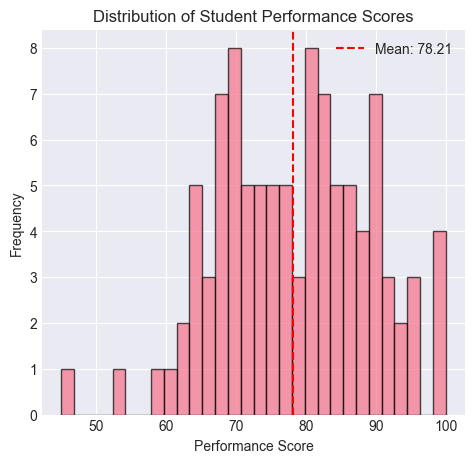

In [48]:
# 1. Distribution of performance scores
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(data['performance_score'], bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Performance Score')
plt.ylabel('Frequency')
plt.title('Distribution of Student Performance Scores')
plt.axvline(data['performance_score'].mean(), color='red', linestyle='--', label=f'Mean: {data["performance_score"].mean():.2f}')
plt.legend()




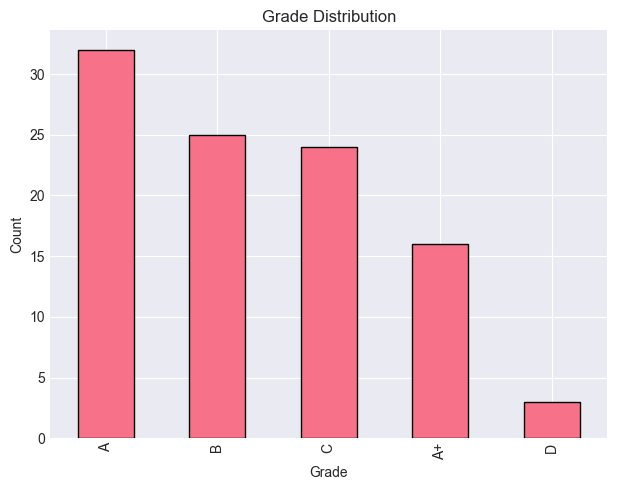

In [49]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 2)
data['grade'].value_counts().plot(kind='bar', edgecolor='black')
plt.xlabel('Grade')
plt.ylabel('Count')
plt.title('Grade Distribution')
plt.tight_layout()
plt.savefig('../static/score_distribution.png')
plt.show()

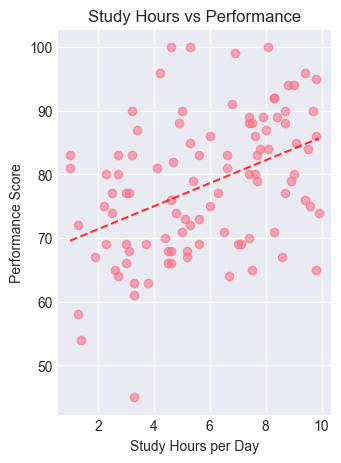

In [50]:
# 2. Study hours vs performance
plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
plt.scatter(data['study_hours'], data['performance_score'], alpha=0.6)
plt.xlabel('Study Hours per Day')
plt.ylabel('Performance Score')
plt.title('Study Hours vs Performance')
# Add trend line
z = np.polyfit(data['study_hours'], data['performance_score'], 1)
p = np.poly1d(z)
plt.plot(data['study_hours'].sort_values(), p(data['study_hours'].sort_values()), "r--", alpha=0.8)

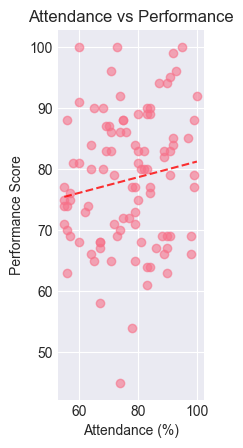

In [51]:
# 3. Attendance vs performance
plt.subplot(1, 3, 2)
plt.scatter(data['attendance_percentage'], data['performance_score'], alpha=0.6)
plt.xlabel('Attendance (%)')
plt.ylabel('Performance Score')
plt.title('Attendance vs Performance')
z = np.polyfit(data['attendance_percentage'], data['performance_score'], 1)
p = np.poly1d(z)
plt.plot(data['attendance_percentage'].sort_values(), p(data['attendance_percentage'].sort_values()), "r--", alpha=0.8)

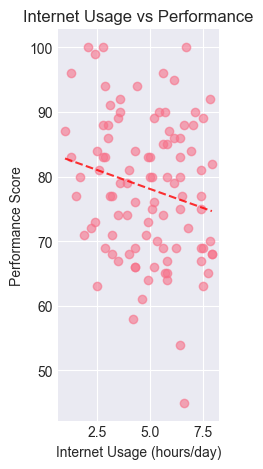

In [52]:
plt.subplot(1, 3, 3)
plt.scatter(data['internet_usage_hours'], data['performance_score'], alpha=0.6)
plt.xlabel('Internet Usage (hours/day)')
plt.ylabel('Performance Score')
plt.title('Internet Usage vs Performance')

z = np.polyfit(data['internet_usage_hours'], data['performance_score'], 1)
p = np.poly1d(z)
plt.plot(
    data['internet_usage_hours'].sort_values(),
    p(data['internet_usage_hours'].sort_values()),
    "r--",
    alpha=0.8
)

plt.tight_layout()
plt.savefig('../static/correlations.png')
plt.show()

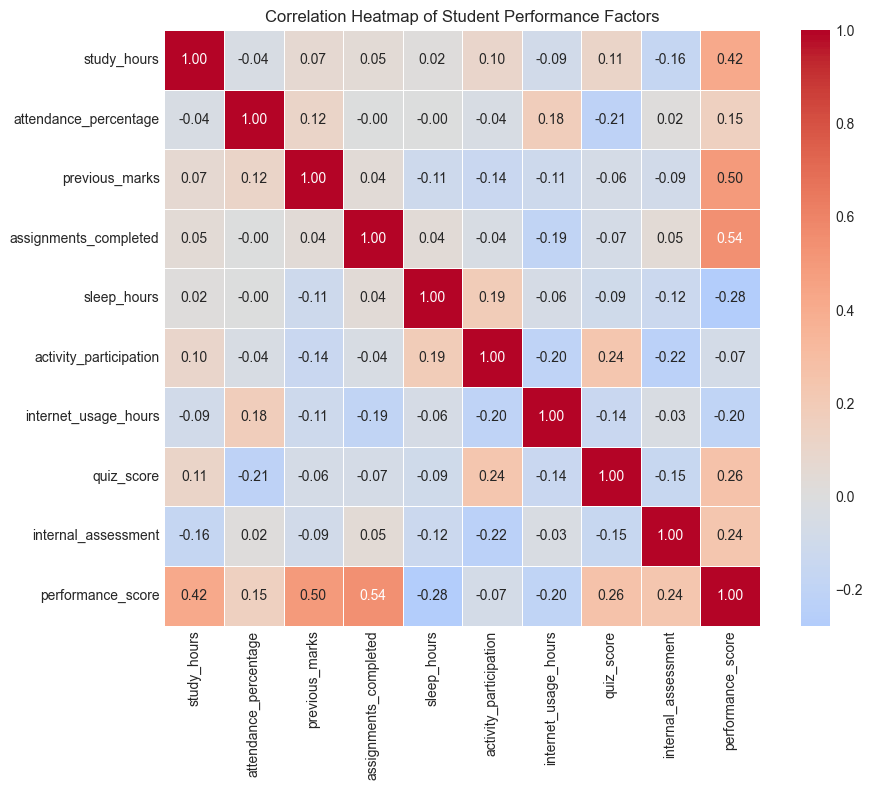

In [56]:
# 5. Correlation heatmap
plt.figure(figsize=(10, 8))
correlation_matrix = data[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, linewidths=0.5)
plt.title('Correlation Heatmap of Student Performance Factors')
plt.tight_layout()
plt.savefig('../static/heatmap.png')
plt.show()


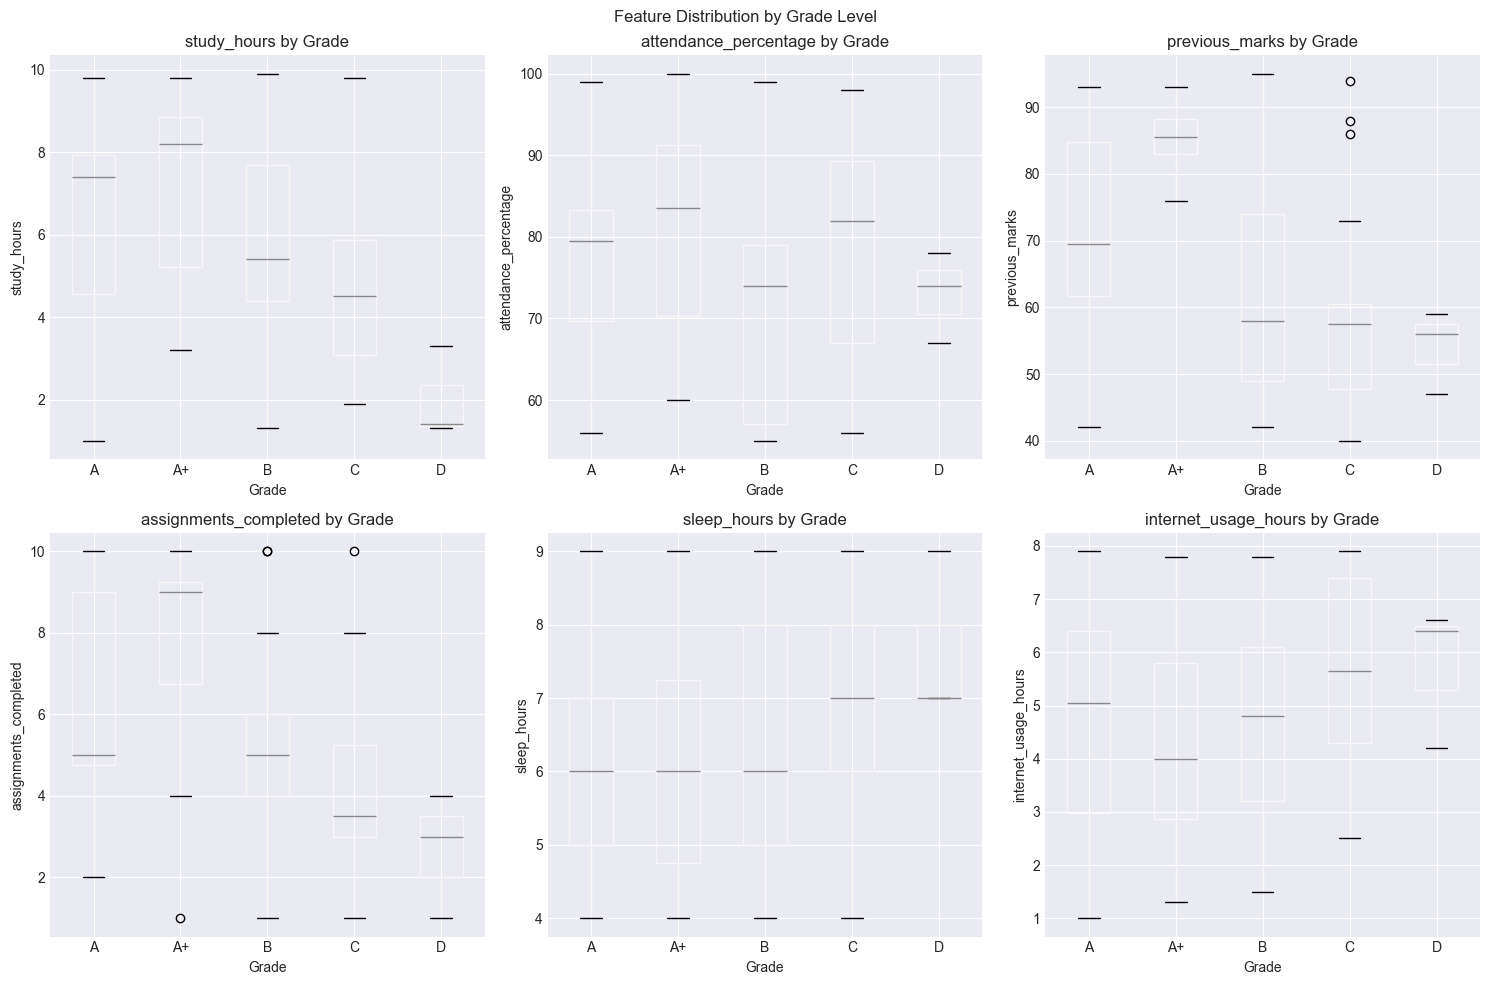

In [59]:

# 6. Box plots for grades vs features
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

features = [
    'study_hours',
    'attendance_percentage',
    'previous_marks',
    'assignments_completed',
    'sleep_hours',
    'internet_usage_hours'
]

for idx, feature in enumerate(features):
    row = idx // 3
    col = idx % 3
    data.boxplot(column=feature, by='grade', ax=axes[row, col])
    axes[row, col].set_title(f'{feature} by Grade')
    axes[row, col].set_xlabel('Grade')
    axes[row, col].set_ylabel(feature)

plt.suptitle('Feature Distribution by Grade Level')
plt.tight_layout()
plt.savefig('../static/grade_analysis.png')
plt.show()
